### Simulation parameters


In [1]:
from common.utils import (
    omega_c,
    default_three_phase_protocol,
)

from pathlib import Path

%load_ext autoreload
%autoreload 2

N = 20
gamma = 1.0
Omega_ratio = 0.4
delta0 = 1.0

N_J = N // 2
Omega0 = Omega_ratio * omega_c(N_J, gamma)

# Define the three-phase protocol with the desired parameters.
phases = default_three_phase_protocol(
    T1=10.0,
    T2=10.0,
    T3=10.0,
    delta0=delta0,
    Omega0=Omega0,
)

seed = 1234
dt = 1e-3
save_every = 20

### Quantum Trajectories

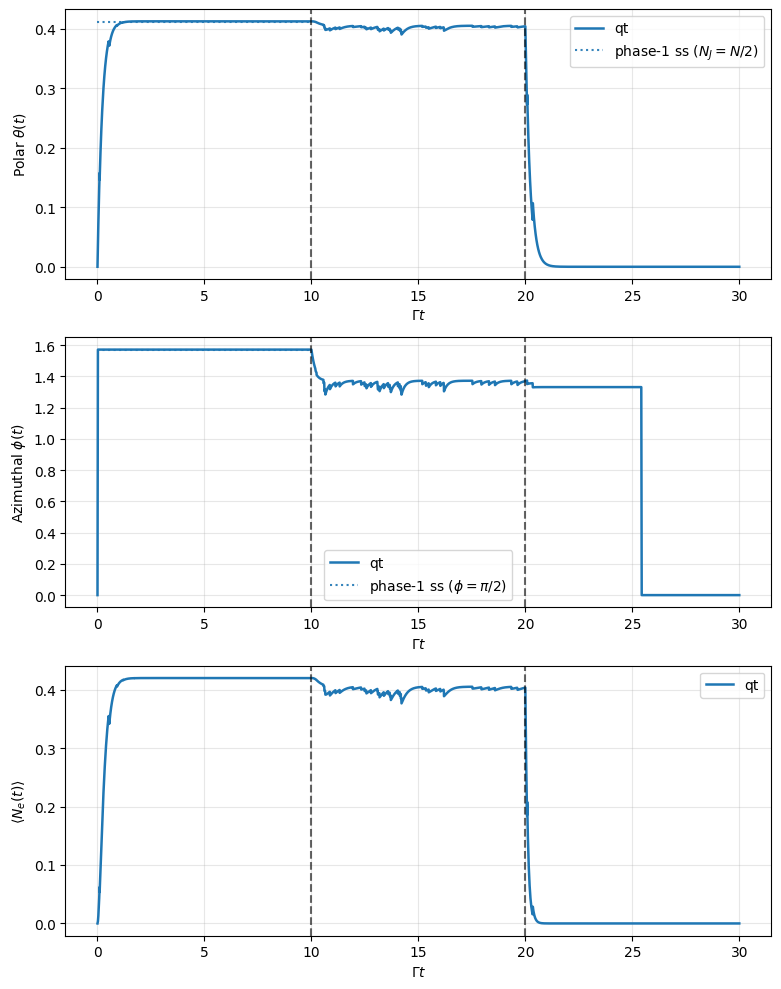

In [2]:
if True:
    from quantum_trajectories.state_helpers import (
        centered_sector_initial_coeffs,
    )
    from quantum_trajectories.sim import (
        simulate_single_trajectory,
    )
    from common.plotting import (
        plot_trajectory_angles_and_excitation,
    )
    from quantum_trajectories.aggregator import (
        trajectory_observables,
        single_trajectory_to_averaged_result,
    )

    # Returns a dictionary of key: sector Nj, value: coefficient for that sector. 
    sector_coeffs = centered_sector_initial_coeffs(N, half_width=0)

    # Simulate a single trajectory
    result = simulate_single_trajectory(
        N=N,
        gamma=gamma,
        phases=phases,
        sector_coeffs=sector_coeffs,
        dt=dt,
        save_every=save_every,
        seed=seed,
    )

    obs_avg = trajectory_observables(result)
    avg_result = single_trajectory_to_averaged_result(result, obs_avg)


    # fig, axes = plot_trajectory_angles_and_excitation(result, phases)
    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    fig, axes = plot_trajectory_angles_and_excitation(
        avg_result,
        phases,
        output_path=output_dir / "qt_single.png",
    )

### Quantum Trajectories Ensamble

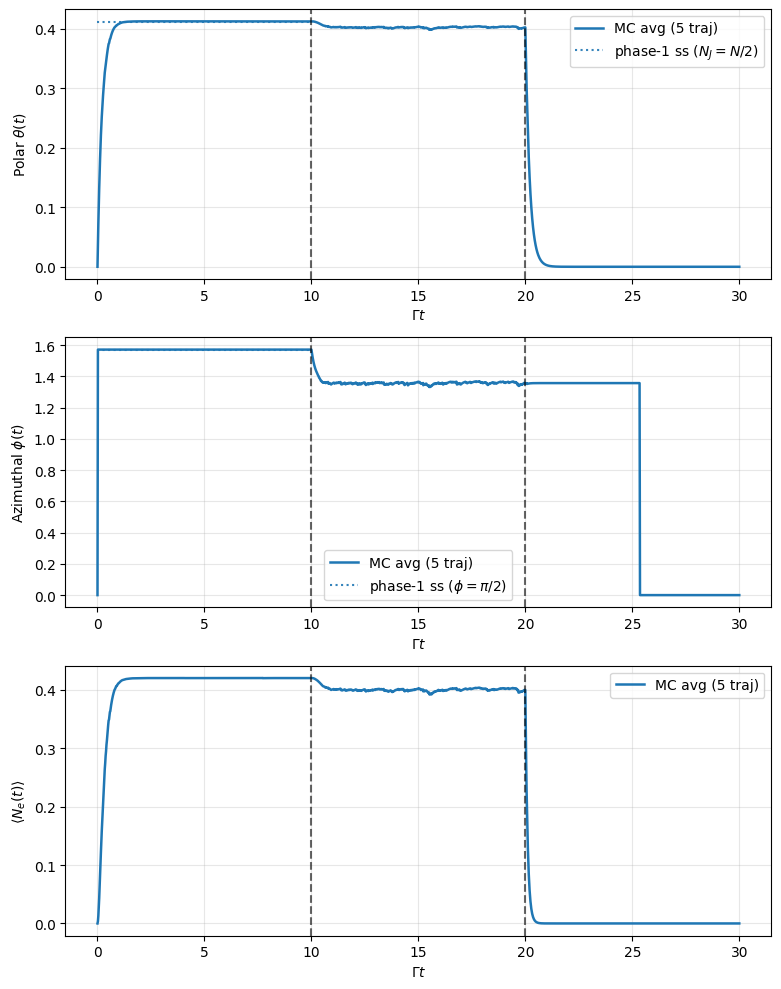

In [3]:
if True:
    from quantum_trajectories.state_helpers import centered_sector_initial_coeffs
    from quantum_trajectories.ensamble_sim import run_trajectory_ensemble
    from quantum_trajectories.aggregator import (
        ensemble_observables,
        make_averaged_result
    )  
    from common.plotting import plot_trajectory_angles_and_excitation

    sector_coeffs = centered_sector_initial_coeffs(N, half_width=0)

    ensemble = run_trajectory_ensemble(
        N=N,
        gamma=gamma,
        phases=phases,
        sector_coeffs=sector_coeffs,
        dt=dt,
        save_every=save_every,
        seed=seed,
        ntraj=5,
    )

    obs_avg = ensemble_observables(ensemble)
    avg_result = make_averaged_result(ensemble, obs_avg)

    output_dir = Path("output")
    output_dir.mkdir(exist_ok=True)
    fig, axes = plot_trajectory_angles_and_excitation(
        avg_result,
        phases,
        output_path=output_dir / "qt_ensable.png",
        show_spread=False,
)

### Qutip Quantum Trajectories

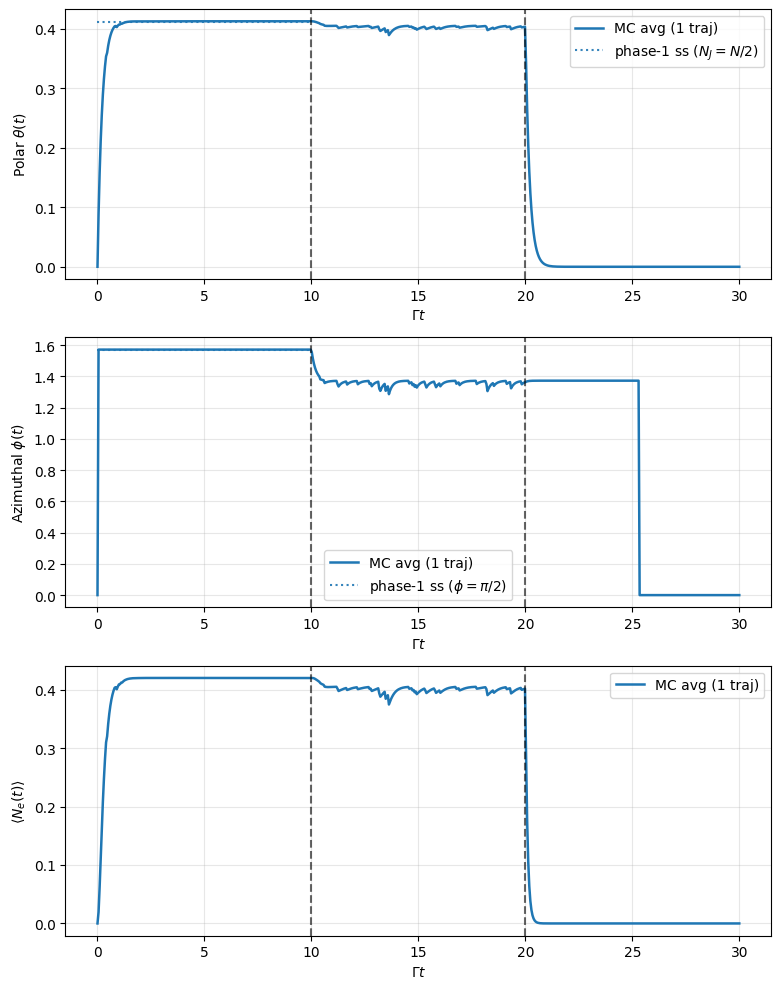

In [4]:
if True:
    from quantum_trajectories_qutip.sim import (
        simulate_fixed_nj_me_trajectory,
        simulate_fixed_nj_mc_trajectory
    )
    from quantum_trajectories_qutip.aggregator import (
        qutip_fixed_nj_mcsolve_observables,
    )
    from common.plotting import (
        plot_qutip_angles_and_excitation,
    )


    qt_sim = simulate_fixed_nj_mc_trajectory(
        N=N,
        gamma=gamma,
        phases=phases,
        num_points=600,
        ntraj=1,
        seed=1234,
    )

    obs = qutip_fixed_nj_mcsolve_observables(qt_sim)

    fig, axes = plot_trajectory_angles_and_excitation(
        obs,
        phases,
        output_path=output_dir / "qt_qutip.png",
    )

In [5]:
# from squeezing_parameter import plot_generalized_xi

# %load_ext autoreload
# %autoreload 2

# # Steady state angles
# theta_ss, phi_ss = phase1_ss_angles_for_nj(N_J, Omega0, gamma)

# # tilde_theta, tilde_phi are the phase-1 reference angles used to define |1>
# xi_data, fig, ax = plot_generalized_xi(
#     result,
#     phases,
#     tilde_theta=theta_ss,
#     tilde_phi=phi_ss,
#     output_path="generalized_xi.png",
# )